In [2]:
%pip install xgboost streamlit folium streamlit-folium geopy pandas numpy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached streamlit_folium-0.27.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached xyzservices-2026.3.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached geographiclib-2.1-py3-none-any.whl.metadata (1.6 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached streamlit_folium-0.27.1-py3-none-any.whl (529 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached geographiclib-2.1-py3-none-any.whl (40 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)
Using cached xyzservices-2026.3.0-py3-none-any.whl (94 kB)

   ---------------------------------------- 0/7 [xyzservices]
   ----- ---------------------------------- 1/7 [geographiclib]

# Sosso Trajet — Modélisation XGBoost

**Hackathon DATA 4 CHANGE | Projet 3 | Talent Tally × MP3**

Ce notebook entraîne un modèle XGBoostRegressor pour prédire le `prix_eco` d'une course Yango,  
puis dérive les prix `confort` et `confort_plus` via des ratios médians calculés dans le notebook de nettoyage.

**Stratégie** :  
- Cible : `log_prix_eco` (transformation log pour stabiliser la variance + robustesse aux outliers)  
- Modèle : **XGBoostRegressor** (meilleur choix pour données tabulaires hétérogènes)  
- Optimisation : RandomizedSearchCV (50 itérations, CV 5-fold)  
- Évaluation : MAE, RMSE, R² — sur log et sur prix réel (FCFA)

**Entrée** : `SossoTrajet_Clean.csv` (7 173 lignes × 21 colonnes)  
**Sortie** : modèle entraîné + prédictions des 3 prix

## 1. Imports & chargement

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [4]:
# Charger le dataset nettoyé
df = pd.read_csv('SossoTrajet_Clean.csv')
print(f"Chargement : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()

Chargement : 7173 lignes x 21 colonnes


,id_course,ville,depart,arrivee,duree_estimee,distance,prix_eco,prix_confort,prix_confort_plus,heure_plage,disponibilite_vehicules,heure_plage_imputed,heure_num,is_pointe,is_nuit,dispo_ordinal,ville_encoded,vitesse_kmh,log_distance,log_duree,log_prix_eco
0,1,Douala,Marché de Bonamoussadi,Russian International School Douala,6.0,3.457,750.0,850.0,950.0,13h–14h,vert,0,13,0,0,0,0,34.570000,1.494476,1.945910,6.621406
1,3,Douala,Akwa Palace,Logbaba yuliana,33.0,9.347,1750.0,2350.0,2850.0,13h–14h,vert,0,13,0,0,0,0,16.994545,2.336697,3.526361,7.467942
2,4,Douala,Santa lucia bonaberie,Lycée des Palmiers,47.0,14.393,2600.0,3500.0,4300.0,14h–15h,vert,0,14,0,0,0,0,18.374043,2.733913,3.871201,7.863651
3,5,Douala,Marché de Bonamoussadi,Collège évangélique de newbell,34.0,9.964,2650.0,2800.0,3150.0,13h–14h,jaune,0,13,0,0,1,0,17.583529,2.394617,3.555348,7.882692
4,6,Douala,Marché de Bonamoussadi,Hôtel la Falaise Bonanjo,26.0,8.911,1700.0,2300.0,2800.0,13h–14h,vert,0,13,0,0,0,0,20.563846,2.293645,3.295837,7.438972


In [5]:
# Aperçu rapide
print("Types:")
print(df.dtypes)
print("\nValeurs manquantes:")
print(df.isnull().sum())

Types:
id_course                    int64
ville                       object
depart                      object
arrivee                     object
duree_estimee              float64
distance                   float64
prix_eco                   float64
prix_confort               float64
prix_confort_plus          float64
heure_plage                 object
disponibilite_vehicules     object
heure_plage_imputed          int64
heure_num                    int64
is_pointe                    int64
is_nuit                      int64
dispo_ordinal                int64
ville_encoded                int64
vitesse_kmh                float64
log_distance               float64
log_duree                  float64
log_prix_eco               float64
dtype: object

Valeurs manquantes:
id_course                     0
ville                         0
depart                        0
arrivee                       0
duree_estimee                 0
distance                      0
prix_eco                    109

## 2. Définition des features & de la cible

**Justification du choix des features** : on exclut les colonnes brutes (`distance`, `duree_estimee`, `prix_confort`, `prix_confort_plus`) pour éviter la fuite de données.  
On utilise uniquement les features encodées et transformées produites en Phase B du nettoyage.

In [6]:
# Features sélectionnées (issues du Feature Engineering — Phase B)
FEATURES = [
    'log_distance',       # B7 — distance log-transformée (neutralise outliers)
    'log_duree',          # B7 — durée log-transformée
    'vitesse_kmh',        # B6 — vitesse estimée (proxy de congestion)
    'is_pointe',          # B2 — heure de pointe (0/1)
    'is_nuit',            # B3 — heure de nuit (0/1)
    'dispo_ordinal',      # B4 — disponibilité véhicules (0=vert, 3=rouge)
    'heure_num',          # B1 — heure de la journée (0-23)
    'ville_encoded',      # B5 — Yaoundé=1, Douala=0
    'heure_plage_imputed' # A4 — flag imputation heure inconnue
]

TARGET = 'log_prix_eco'  # B8 — cible log-transformée

print(f"Features sélectionnées ({len(FEATURES)}) : {FEATURES}")
print(f"Cible : {TARGET}")

Features sélectionnées (9) : ['log_distance', 'log_duree', 'vitesse_kmh', 'is_pointe', 'is_nuit', 'dispo_ordinal', 'heure_num', 'ville_encoded', 'heure_plage_imputed']
Cible : log_prix_eco


In [7]:
# Calcul des ratios médians (dérivation confort / confort+ après prédiction)
# Ces ratios ont été calculés dans SossoTrajet_Nettoyage.ipynb (section 4)
df_prix = df.dropna(subset=['prix_eco', 'prix_confort', 'prix_confort_plus'])

RATIO_CONFORT      = (df_prix['prix_confort']      / df_prix['prix_eco']).median()
RATIO_CONFORT_PLUS = (df_prix['prix_confort_plus'] / df_prix['prix_eco']).median()

print(f"Ratio médian confort / eco       : {RATIO_CONFORT:.4f}")
print(f"Ratio médian confort_plus / eco  : {RATIO_CONFORT_PLUS:.4f}")

Ratio médian confort / eco       : 1.3000
Ratio médian confort_plus / eco  : 1.7333


In [8]:
# Filtrage : ne garder que les lignes avec cible disponible
df_model = df.dropna(subset=[TARGET] + FEATURES).copy()
print(f"Lignes disponibles pour la modélisation : {len(df_model)} / {len(df)}")

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")

Lignes disponibles pour la modélisation : 7064 / 7173
Shape X : (7064, 9)
Shape y : (7064,)


## 3. Analyse exploratoire des features

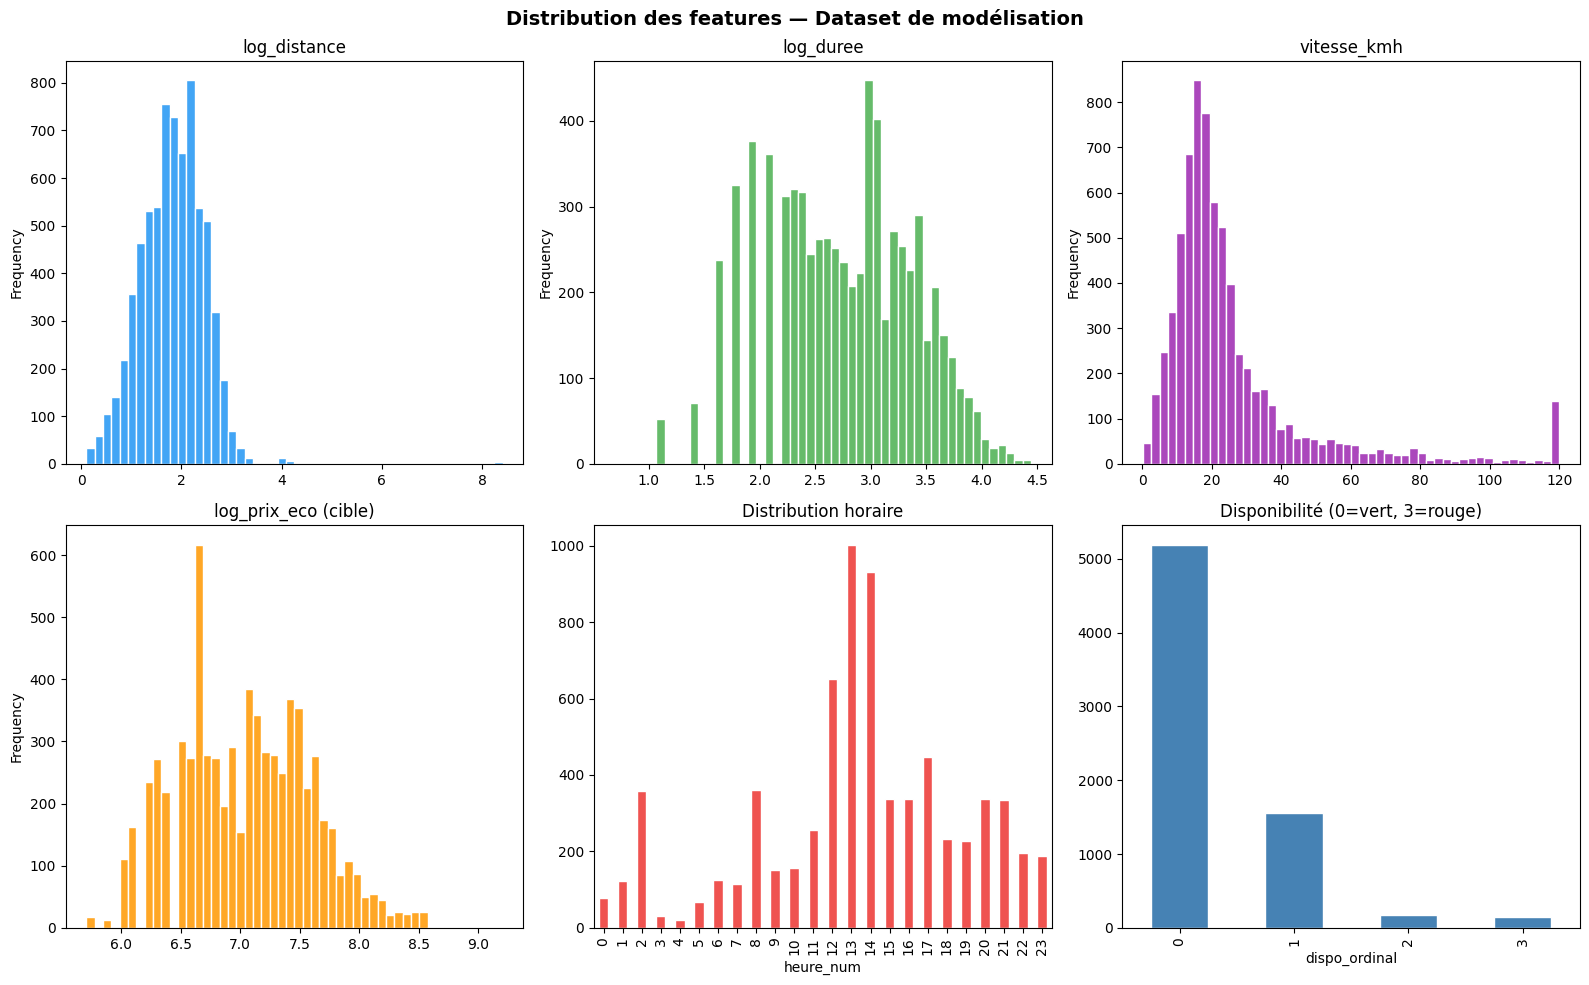

In [9]:
# Distribution des features numériques clés
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

df_model['log_distance'].plot(kind='hist', bins=50, ax=axes[0,0], color='#42A5F5', edgecolor='white')
axes[0,0].set_title("log_distance")

df_model['log_duree'].plot(kind='hist', bins=50, ax=axes[0,1], color='#66BB6A', edgecolor='white')
axes[0,1].set_title("log_duree")

df_model['vitesse_kmh'].plot(kind='hist', bins=50, ax=axes[0,2], color='#AB47BC', edgecolor='white')
axes[0,2].set_title("vitesse_kmh")

df_model['log_prix_eco'].plot(kind='hist', bins=50, ax=axes[1,0], color='#FFA726', edgecolor='white')
axes[1,0].set_title("log_prix_eco (cible)")

df_model['heure_num'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='#EF5350', edgecolor='white')
axes[1,1].set_title("Distribution horaire")

df_model['dispo_ordinal'].value_counts().sort_index().plot(kind='bar', ax=axes[1,2], color='steelblue', edgecolor='white')
axes[1,2].set_title("Disponibilité (0=vert, 3=rouge)")

plt.suptitle("Distribution des features — Dataset de modélisation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

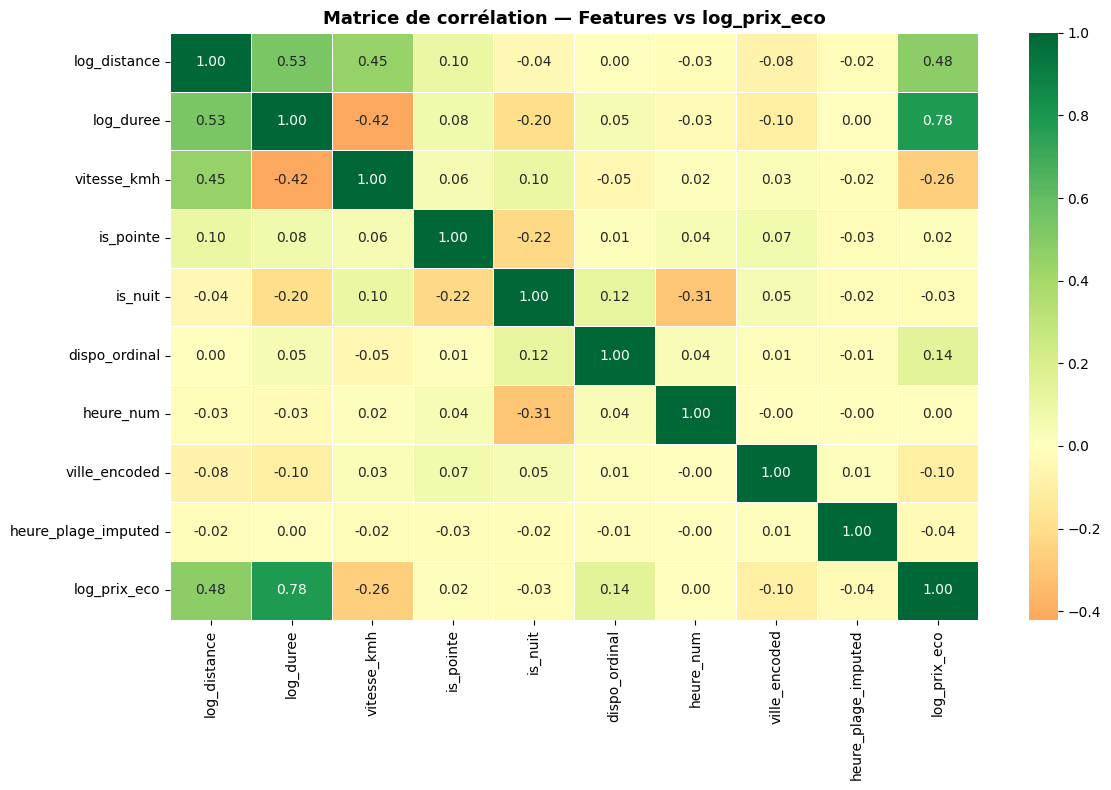

In [10]:
# Matrice de corrélation features vs cible
corr_data = X.copy()
corr_data['log_prix_eco'] = y.values

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_data.corr(),
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5
)
plt.title("Matrice de corrélation — Features vs log_prix_eco", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Corrélations triées avec la cible
corrs = corr_data.corr()['log_prix_eco'].drop('log_prix_eco').sort_values(ascending=False)
print("=== Corrélations avec log_prix_eco ===")
print(corrs.round(3))

=== Corrélations avec log_prix_eco ===
log_duree              0.778
log_distance           0.479
dispo_ordinal          0.141
is_pointe              0.017
heure_num              0.001
is_nuit               -0.025
heure_plage_imputed   -0.036
ville_encoded         -0.100
vitesse_kmh           -0.261
Name: log_prix_eco, dtype: float64


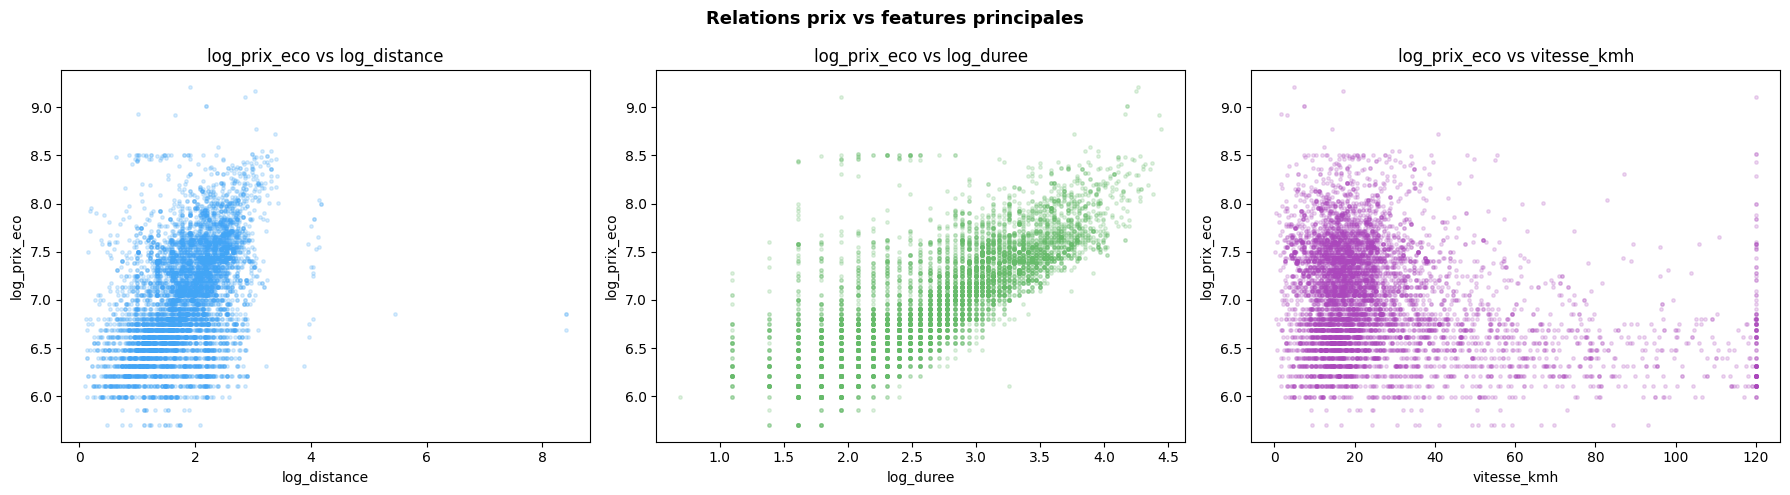

In [12]:
# Scatter : log_prix_eco vs features les plus corrélées
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat, color in zip(axes,
    ['log_distance', 'log_duree', 'vitesse_kmh'],
    ['#42A5F5', '#66BB6A', '#AB47BC']):
    axes_idx = list(axes).index(ax)
    ax.scatter(df_model[feat], df_model['log_prix_eco'], alpha=0.2, s=6, color=color)
    ax.set_xlabel(feat)
    ax.set_ylabel('log_prix_eco')
    ax.set_title(f"log_prix_eco vs {feat}")

plt.suptitle("Relations prix vs features principales", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Split Train / Test

**Justification** : 80% train / 20% test avec `random_state=42` pour la reproductibilité.  
Pas de stratification nécessaire ici (régression, distribution continue).

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.1f}%)")

Train : 5651 lignes (80.0%)
Test  : 1413 lignes (20.0%)


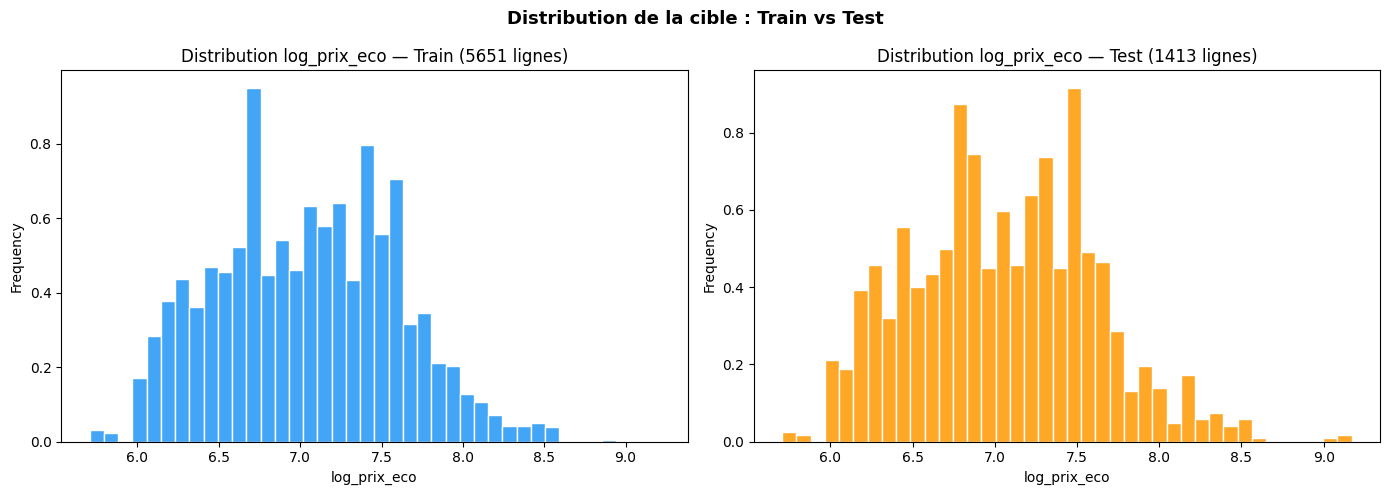

Train — mean: 7.045, std: 0.551
Test  — mean: 7.055, std: 0.554


In [14]:
# Vérifier la distribution de la cible sur train vs test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_train.plot(kind='hist', bins=40, ax=axes[0], color='#42A5F5', edgecolor='white', density=True)
axes[0].set_title(f"Distribution log_prix_eco — Train ({len(y_train)} lignes)")
axes[0].set_xlabel("log_prix_eco")

y_test.plot(kind='hist', bins=40, ax=axes[1], color='#FFA726', edgecolor='white', density=True)
axes[1].set_title(f"Distribution log_prix_eco — Test ({len(y_test)} lignes)")
axes[1].set_xlabel("log_prix_eco")

plt.suptitle("Distribution de la cible : Train vs Test", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Train — mean: {y_train.mean():.3f}, std: {y_train.std():.3f}")
print(f"Test  — mean: {y_test.mean():.3f}, std: {y_test.std():.3f}")

## 5. Modèle Baseline XGBoost

**Justification** : un modèle avec paramètres par défaut permet d'établir une performance de référence  
avant optimisation. XGBoost est choisi pour sa robustesse sur données tabulaires hétérogènes et sa gestion native des relations non-linéaires.

In [15]:
# Entraînement baseline
xgb_baseline = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_baseline.fit(X_train, y_train)
y_pred_bl = xgb_baseline.predict(X_test)

# Métriques sur log_prix_eco
mae_bl_log  = mean_absolute_error(y_test, y_pred_bl)
rmse_bl_log = np.sqrt(mean_squared_error(y_test, y_pred_bl))
r2_bl_log   = r2_score(y_test, y_pred_bl)

# Métriques sur prix_eco réel (FCFA) via back-transformation
y_test_real  = np.expm1(y_test)
y_pred_bl_real = np.expm1(y_pred_bl)

mae_bl_real  = mean_absolute_error(y_test_real, y_pred_bl_real)
rmse_bl_real = np.sqrt(mean_squared_error(y_test_real, y_pred_bl_real))
r2_bl_real   = r2_score(y_test_real, y_pred_bl_real)

print("=== BASELINE — Métriques sur log_prix_eco ===")
print(f"MAE  : {mae_bl_log:.4f}")
print(f"RMSE : {rmse_bl_log:.4f}")
print(f"R²   : {r2_bl_log:.4f}")

print("\n=== BASELINE — Métriques sur prix_eco (FCFA) ===")
print(f"MAE  : {mae_bl_real:.0f} FCFA")
print(f"RMSE : {rmse_bl_real:.0f} FCFA")
print(f"R²   : {r2_bl_real:.4f}")

=== BASELINE — Métriques sur log_prix_eco ===
MAE  : 0.1921
RMSE : 0.2910
R²   : 0.7239

=== BASELINE — Métriques sur prix_eco (FCFA) ===
MAE  : 267 FCFA
RMSE : 545 FCFA
R²   : 0.6120


## 6. Optimisation des hyperparamètres — RandomizedSearchCV

**Justification** : RandomizedSearchCV est préféré à GridSearchCV pour explorer un espace large  
sans exploser le temps de calcul. 50 itérations × CV 5-fold = 250 entraînements.  
Paramètres explorés : profondeur, taux d'apprentissage, régularisation L1/L2, sous-échantillonnage.

In [16]:
# Grille d'hyperparamètres
param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'max_depth'        : [3, 4, 5, 6, 7],
    'min_child_weight' : [1, 3, 5],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'        : [0, 0.01, 0.1, 1],     # L1
    'reg_lambda'       : [0.1, 1, 5, 10]         # L2
}

xgb_model = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Lancement de la recherche (50 itérations × CV 5-fold)...")
random_search.fit(X_train, y_train)
print("Recherche terminée ✓")

Lancement de la recherche (50 itérations × CV 5-fold)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Recherche terminée ✓


In [17]:
print("=== Meilleurs hyperparamètres ===")
for param, value in sorted(random_search.best_params_.items()):
    print(f"  {param:20s}: {value}")
print(f"\nMeilleur score CV (RMSE log) : {-random_search.best_score_:.4f}")

=== Meilleurs hyperparamètres ===
  colsample_bytree    : 0.7
  learning_rate       : 0.05
  max_depth           : 7
  min_child_weight    : 5
  n_estimators        : 300
  reg_alpha           : 0.1
  reg_lambda          : 5
  subsample           : 0.9

Meilleur score CV (RMSE log) : 0.2861


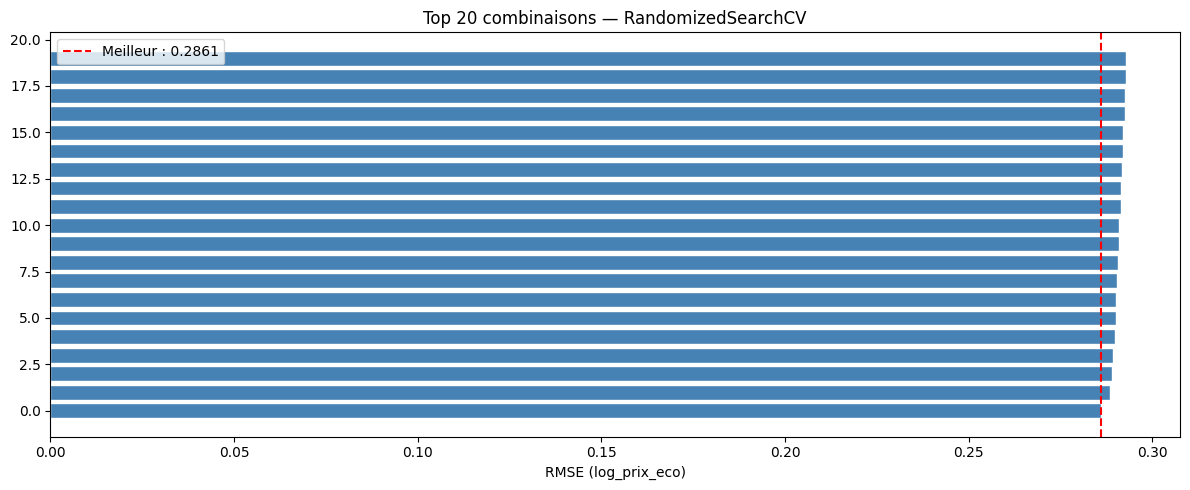

In [18]:
# Évolution des scores CV (top 20 itérations)
results_df = pd.DataFrame(random_search.cv_results_)
results_df = results_df.sort_values('rank_test_score').head(20)

plt.figure(figsize=(12, 5))
plt.barh(
    range(len(results_df)),
    -results_df['mean_test_score'],
    color='steelblue',
    edgecolor='white'
)
plt.axvline(x=-random_search.best_score_, color='red', linestyle='--', label=f'Meilleur : {-random_search.best_score_:.4f}')
plt.xlabel('RMSE (log_prix_eco)')
plt.title('Top 20 combinaisons — RandomizedSearchCV')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Évaluation du meilleur modèle

In [19]:
# Meilleur modèle
best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)

# Sur log_prix_eco
mae_log  = mean_absolute_error(y_test, y_pred_best)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_log   = r2_score(y_test, y_pred_best)

# Sur prix_eco réel (FCFA)
y_pred_real = np.expm1(y_pred_best)

mae_real  = mean_absolute_error(y_test_real, y_pred_real)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2_real   = r2_score(y_test_real, y_pred_real)

print("=== MEILLEUR MODÈLE — Métriques sur log_prix_eco ===")
print(f"MAE  : {mae_log:.4f}")
print(f"RMSE : {rmse_log:.4f}")
print(f"R²   : {r2_log:.4f}")

print("\n=== MEILLEUR MODÈLE — Métriques sur prix_eco (FCFA) ===")
print(f"MAE  : {mae_real:.0f} FCFA")
print(f"RMSE : {rmse_real:.0f} FCFA")
print(f"R²   : {r2_real:.4f}")

=== MEILLEUR MODÈLE — Métriques sur log_prix_eco ===
MAE  : 0.1903
RMSE : 0.2849
R²   : 0.7353

=== MEILLEUR MODÈLE — Métriques sur prix_eco (FCFA) ===
MAE  : 269 FCFA
RMSE : 557 FCFA
R²   : 0.5940


In [20]:
# Comparaison Baseline vs Modèle optimisé
comparison = pd.DataFrame({
    'Métrique'   : ['MAE (FCFA)', 'RMSE (FCFA)', 'R²'],
    'Baseline'   : [round(mae_bl_real, 0), round(rmse_bl_real, 0), round(r2_bl_real, 4)],
    'Optimisé'   : [round(mae_real, 0),    round(rmse_real, 0),    round(r2_real, 4)]
})
print(comparison.to_string(index=False))

   Métrique  Baseline  Optimisé
 MAE (FCFA)   267.000   269.000
RMSE (FCFA)   545.000   557.000
         R²     0.612     0.594


## 8. Validation croisée 5-fold

**Justification** : la validation croisée garantit que les performances ne dépendent pas  
du hasard du split train/test. Un R² stable et élevé sur les 5 folds valide la robustesse du modèle.

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2   = cross_val_score(best_model, X, y, cv=kf, scoring='r2',                        n_jobs=-1)
cv_rmse = cross_val_score(best_model, X, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)

print("=== Validation croisée 5-fold ===")
print("\nR² par fold :")
for i, s in enumerate(cv_r2, 1):
    print(f"  Fold {i} : {s:.4f}")
print(f"  Moyenne : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

print("\nRMSE (log) par fold :")
for i, s in enumerate(-cv_rmse, 1):
    print(f"  Fold {i} : {s:.4f}")
print(f"  Moyenne : {(-cv_rmse).mean():.4f} ± {(-cv_rmse).std():.4f}")

=== Validation croisée 5-fold ===

R² par fold :
  Fold 1 : 0.7331
  Fold 2 : 0.7332
  Fold 3 : 0.7368
  Fold 4 : 0.7488
  Fold 5 : 0.7180
  Moyenne : 0.7340 ± 0.0098

RMSE (log) par fold :
  Fold 1 : 0.2861
  Fold 2 : 0.2862
  Fold 3 : 0.2836
  Fold 4 : 0.2768
  Fold 5 : 0.2892
  Moyenne : 0.2844 ± 0.0042


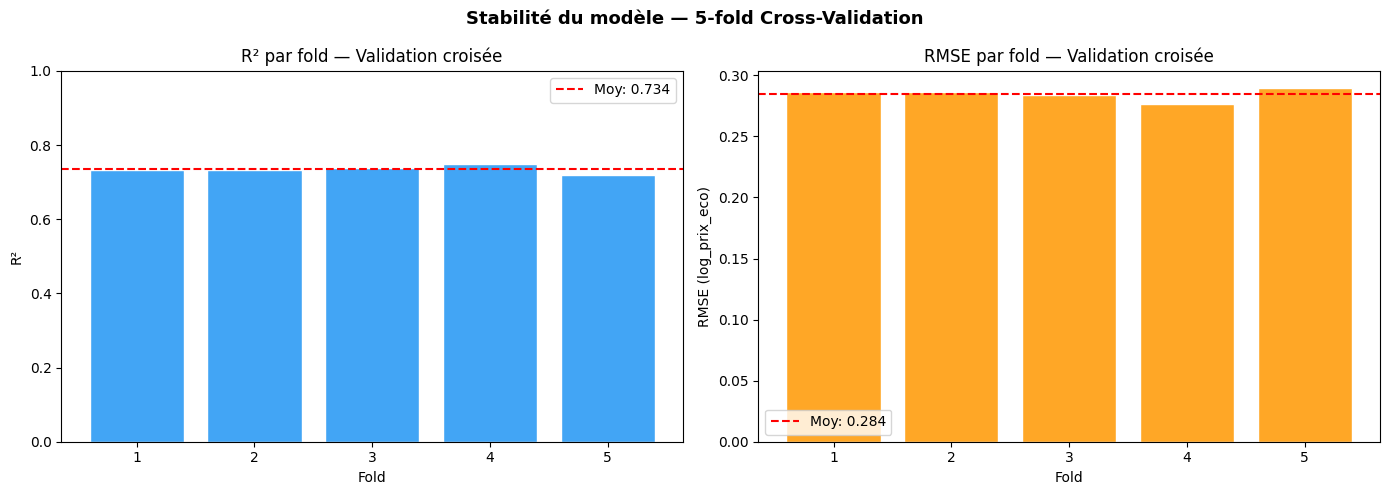

In [22]:
# Visualisation des scores par fold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 6), cv_r2, color='#42A5F5', edgecolor='white')
axes[0].axhline(y=cv_r2.mean(), color='red', linestyle='--', label=f'Moy: {cv_r2.mean():.3f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('R²')
axes[0].set_title('R² par fold — Validation croisée')
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].bar(range(1, 6), -cv_rmse, color='#FFA726', edgecolor='white')
axes[1].axhline(y=(-cv_rmse).mean(), color='red', linestyle='--', label=f'Moy: {(-cv_rmse).mean():.3f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('RMSE (log_prix_eco)')
axes[1].set_title('RMSE par fold — Validation croisée')
axes[1].legend()

plt.suptitle('Stabilité du modèle — 5-fold Cross-Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Visualisations des performances

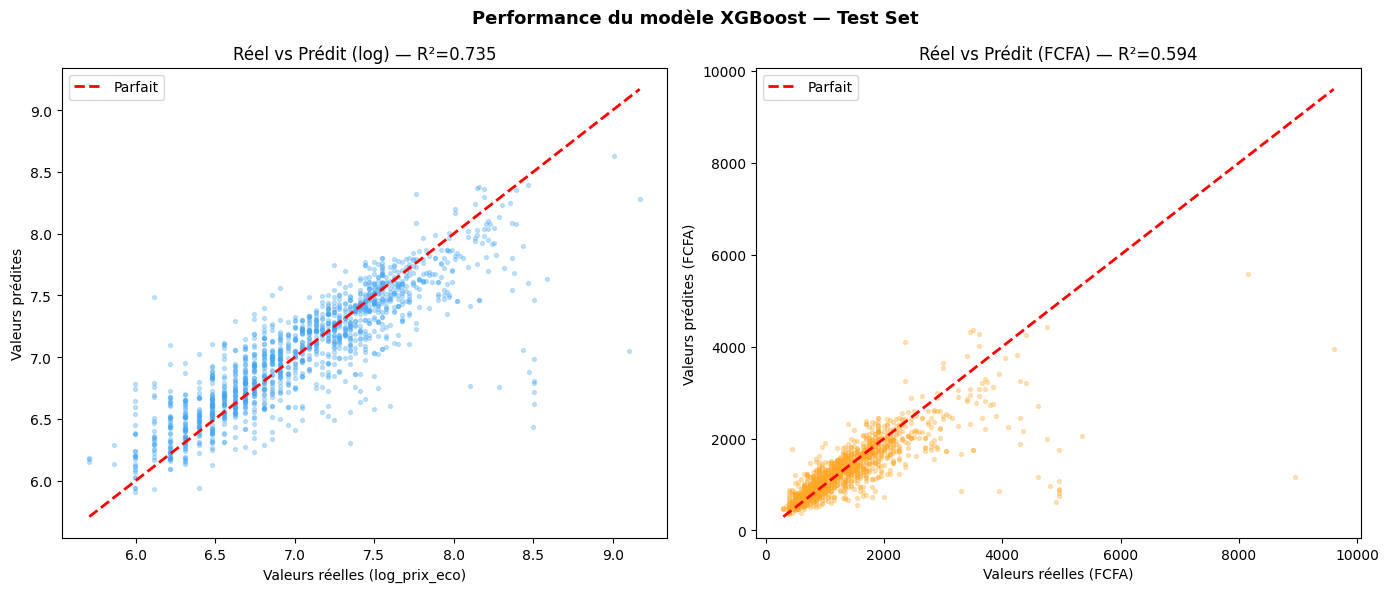

In [23]:
# Valeurs réelles vs Prédictions (log et FCFA)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sur log_prix_eco
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=8, color='#42A5F5')
min_v, max_v = y_test.min(), y_test.max()
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Parfait')
axes[0].set_xlabel('Valeurs réelles (log_prix_eco)')
axes[0].set_ylabel('Valeurs prédites')
axes[0].set_title(f'Réel vs Prédit (log) — R²={r2_log:.3f}')
axes[0].legend()

# Sur prix_eco réel (FCFA)
axes[1].scatter(y_test_real, y_pred_real, alpha=0.3, s=8, color='#FFA726')
min_v, max_v = y_test_real.min(), y_test_real.max()
axes[1].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Parfait')
axes[1].set_xlabel('Valeurs réelles (FCFA)')
axes[1].set_ylabel('Valeurs prédites (FCFA)')
axes[1].set_title(f'Réel vs Prédit (FCFA) — R²={r2_real:.3f}')
axes[1].legend()

plt.suptitle('Performance du modèle XGBoost — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

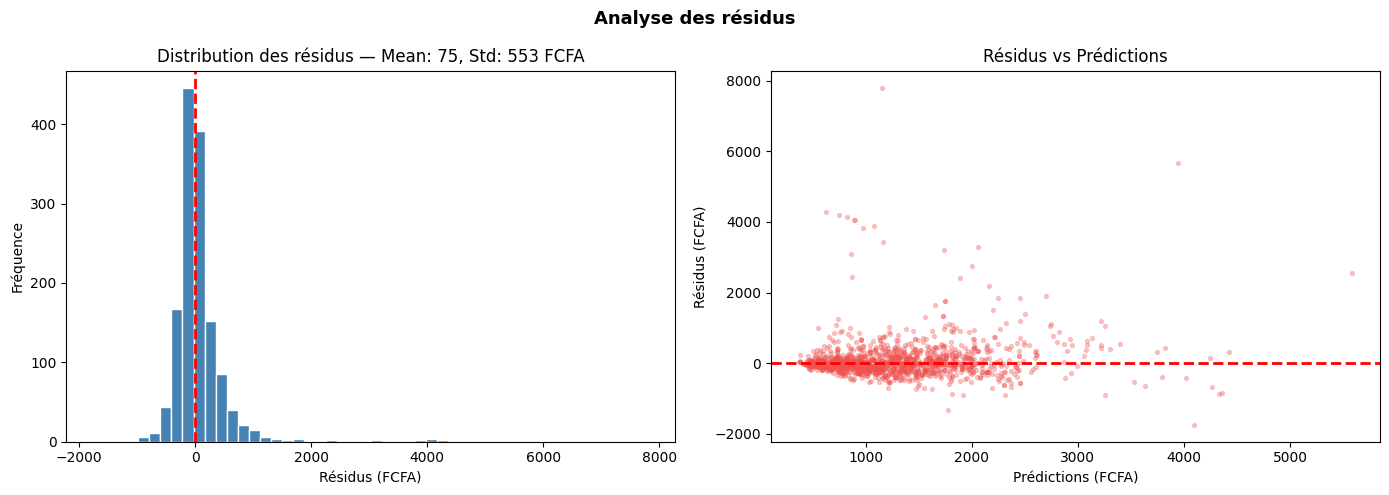

In [24]:
# Distribution et analyse des résidus
residuals = y_test_real - y_pred_real

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Résidus (FCFA)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title(f'Distribution des résidus — Mean: {residuals.mean():.0f}, Std: {residuals.std():.0f} FCFA')

axes[1].scatter(y_pred_real, residuals, alpha=0.3, s=8, color='#EF5350')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Prédictions (FCFA)')
axes[1].set_ylabel('Résidus (FCFA)')
axes[1].set_title('Résidus vs Prédictions')

plt.suptitle('Analyse des résidus', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

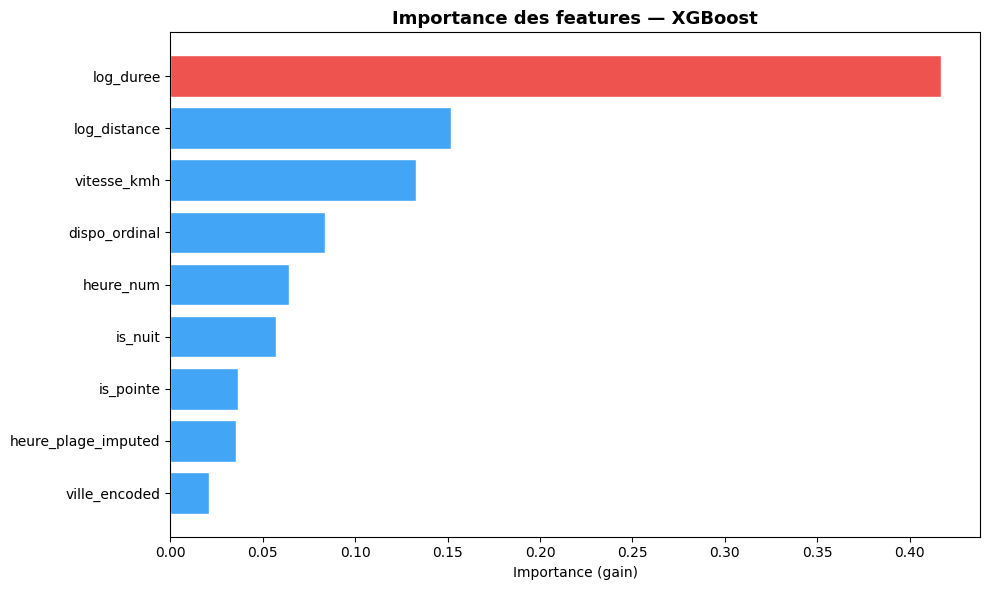


=== Importance des features (triée) ===
            feature  importance
          log_duree    0.417242
       log_distance    0.152005
        vitesse_kmh    0.133097
      dispo_ordinal    0.083426
          heure_num    0.064425
            is_nuit    0.057116
          is_pointe    0.036489
heure_plage_imputed    0.035495
      ville_encoded    0.020706


In [25]:
# Importance des features
feature_importance = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#EF5350' if i == len(feature_importance)-1 else '#42A5F5'
          for i in range(len(feature_importance))]
plt.barh(feature_importance['feature'], feature_importance['importance'], color=colors, edgecolor='white')
plt.xlabel('Importance (gain)')
plt.title('Importance des features — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Importance des features (triée) ===")
print(feature_importance.sort_values('importance', ascending=False).to_string(index=False))

## 10. Prédiction des 3 prix (Éco / Confort / Confort+)

**Stratégie** : on ne prédit qu'un seul modèle (sur `log_prix_eco`), puis on dérive  
les deux autres tarifs par multiplication par le ratio médian calculé en section 2.  
- `prix_confort = prix_eco × 1.3`  
- `prix_confort_plus = prix_eco × 1.727`

In [26]:
def predict_all_prices(model, X_input, ratio_confort=RATIO_CONFORT, ratio_confort_plus=RATIO_CONFORT_PLUS):
    """
    Prédit les 3 tarifs Yango à partir des features d'une course.

    Parameters
    ----------
    model             : XGBoostRegressor entraîné
    X_input           : DataFrame avec les 9 features
    ratio_confort     : ratio médian confort / eco (défaut : 1.3)
    ratio_confort_plus: ratio médian confort_plus / eco (défaut : 1.727)

    Returns
    -------
    DataFrame avec prix_eco_pred, prix_confort_pred, prix_confort_plus_pred
    """
    log_pred  = model.predict(X_input)
    prix_eco  = np.expm1(log_pred)  # back-transformation log1p -> valeur réelle

    return pd.DataFrame({
        'prix_eco_pred'          : np.round(prix_eco, 0),
        'prix_confort_pred'      : np.round(prix_eco * ratio_confort, 0),
        'prix_confort_plus_pred' : np.round(prix_eco * ratio_confort_plus, 0)
    })

print(f"Ratios utilisés :")
print(f"  Confort      : x{RATIO_CONFORT:.4f}")
print(f"  Confort Plus : x{RATIO_CONFORT_PLUS:.4f}")

Ratios utilisés :
  Confort      : x1.3000
  Confort Plus : x1.7333


In [27]:
# Application sur le test set
predictions_test = predict_all_prices(best_model, X_test)
predictions_test = predictions_test.reset_index(drop=True)

# Vraies valeurs pour comparaison
df_test_ref = df_model.loc[X_test.index, ['prix_eco', 'prix_confort', 'prix_confort_plus']].reset_index(drop=True)
comparison_full = pd.concat([df_test_ref, predictions_test], axis=1)

print("=== Exemples de prédictions — Test Set (10 premières lignes) ===")
print(comparison_full.head(10).to_string(index=False))

=== Exemples de prédictions — Test Set (10 premières lignes) ===
 prix_eco  prix_confort  prix_confort_plus  prix_eco_pred  prix_confort_pred  prix_confort_plus_pred
   1100.0        1600.0             2800.0         1254.0             1631.0                  2174.0
   1250.0        1950.0             2100.0         1228.0             1597.0                  2129.0
   1400.0        1700.0             2200.0         1036.0             1347.0                  1797.0
   1900.0           NaN                NaN         1167.0             1517.0                  2023.0
    700.0        1000.0             1300.0          925.0             1202.0                  1603.0
   1400.0        2250.0                NaN         1396.0             1815.0                  2420.0
    500.0        1000.0             1050.0         1033.0             1344.0                  1791.0
    550.0         700.0                NaN          472.0              613.0                   818.0
   2150.0        4400.0   

In [28]:
# Métriques finales sur les 3 prix
print("=== Métriques finales sur les 3 prix (FCFA) ===")
print()

for col_reel, col_pred, label in [
    ('prix_eco',          'prix_eco_pred',          'Prix Eco         '),
    ('prix_confort',      'prix_confort_pred',      'Prix Confort     '),
    ('prix_confort_plus', 'prix_confort_plus_pred', 'Prix Confort Plus'),
]:
    mask = df_test_ref[col_reel].notna()
    real = df_test_ref.loc[mask, col_reel]
    pred = predictions_test.loc[mask, col_pred]
    mae  = mean_absolute_error(real, pred)
    r2   = r2_score(real, pred)
    print(f"{label} — MAE: {mae:6.0f} FCFA  |  R²: {r2:.4f}")

=== Métriques finales sur les 3 prix (FCFA) ===

Prix Eco          — MAE:    270 FCFA  |  R²: 0.5940
Prix Confort      — MAE:    273 FCFA  |  R²: 0.7762
Prix Confort Plus — MAE:    392 FCFA  |  R²: 0.7769


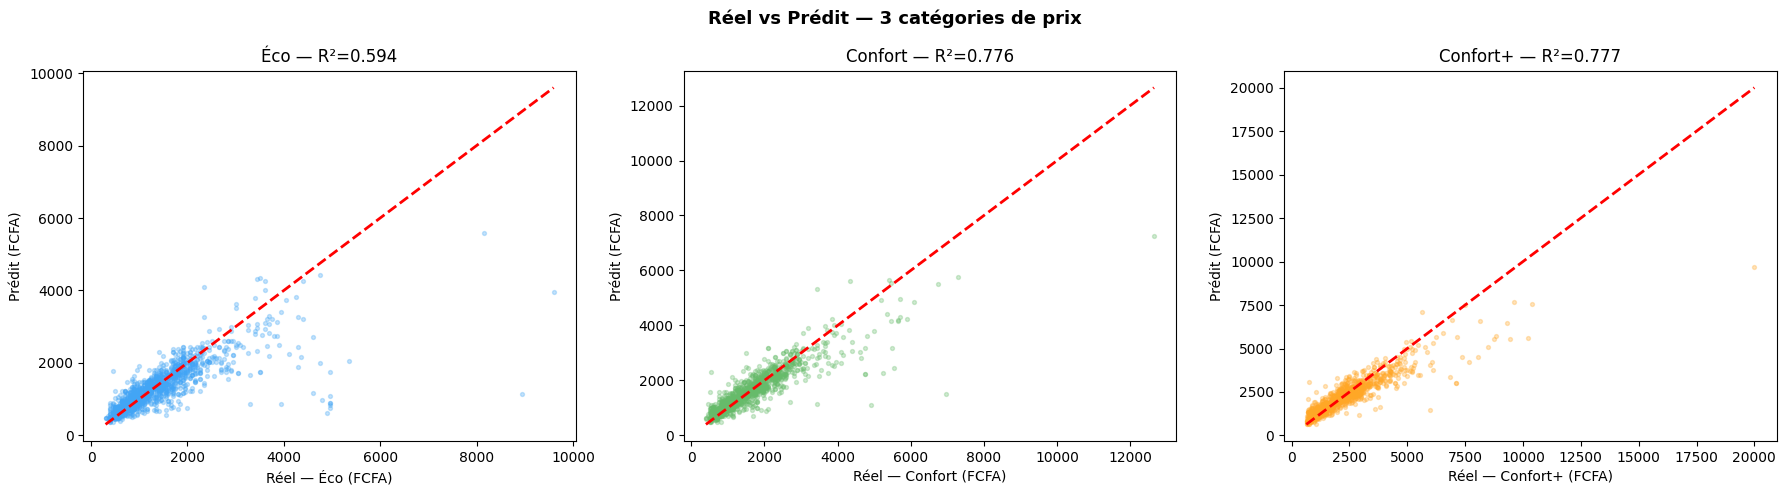

In [29]:
# Visualisation : réel vs prédit pour les 3 prix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#42A5F5', '#66BB6A', '#FFA726']

for ax, col_reel, col_pred, color, label in zip(
    axes,
    ['prix_eco', 'prix_confort', 'prix_confort_plus'],
    ['prix_eco_pred', 'prix_confort_pred', 'prix_confort_plus_pred'],
    colors,
    ['Éco', 'Confort', 'Confort+']
):
    mask   = df_test_ref[col_reel].notna()
    real   = df_test_ref.loc[mask, col_reel]
    pred   = predictions_test.loc[mask, col_pred]
    r2     = r2_score(real, pred)
    min_v  = min(real.min(), pred.min())
    max_v  = max(real.max(), pred.max())

    ax.scatter(real, pred, alpha=0.3, s=8, color=color)
    ax.plot([min_v, max_v], [min_v, max_v], 'r--', lw=2)
    ax.set_xlabel(f'Réel — {label} (FCFA)')
    ax.set_ylabel('Prédit (FCFA)')
    ax.set_title(f'{label} — R²={r2:.3f}')

plt.suptitle('Réel vs Prédit — 3 catégories de prix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Simulation sur une nouvelle course

In [30]:
# Exemple : Course Yaoundé, 10 km, 20 min, heure de pointe
new_trip = pd.DataFrame([{
    'log_distance'      : np.log1p(10),       # 10 km
    'log_duree'         : np.log1p(20),       # 20 minutes
    'vitesse_kmh'       : 10 / (20/60),       # 30 km/h
    'is_pointe'         : 1,                  # Heure de pointe
    'is_nuit'           : 0,                  # Pas la nuit
    'dispo_ordinal'     : 2,                  # Disponibilité orange
    'heure_num'         : 8,                  # 8h du matin
    'ville_encoded'     : 1,                  # Yaoundé
    'heure_plage_imputed': 0                  # Pas imputée
}])

prix = predict_all_prices(best_model, new_trip)

print("=== Simulation — Nouvelle course ===")
print(f"  Ville       : Yaoundé")
print(f"  Distance    : 10 km")
print(f"  Durée       : 20 min")
print(f"  Conditions  : Heure de pointe, dispo orange (x2)")
print()
print(f"  Prix Éco          : {int(prix['prix_eco_pred'].iloc[0]):>6} FCFA")
print(f"  Prix Confort      : {int(prix['prix_confort_pred'].iloc[0]):>6} FCFA")
print(f"  Prix Confort Plus : {int(prix['prix_confort_plus_pred'].iloc[0]):>6} FCFA")

=== Simulation — Nouvelle course ===
  Ville       : Yaoundé
  Distance    : 10 km
  Durée       : 20 min
  Conditions  : Heure de pointe, dispo orange (x2)

  Prix Éco          :   1300 FCFA
  Prix Confort      :   1689 FCFA
  Prix Confort Plus :   2253 FCFA


## 12. Résumé final

In [31]:
print("=" * 60)
print("         RÉSUMÉ — SossoTrajet Modelling (XGBoost)")
print("=" * 60)
print(f"Modèle        : XGBoostRegressor (optimisé — RandomizedSearchCV)")
print(f"Cible         : log_prix_eco → prix_eco (FCFA via expm1)")
print(f"Features      : {len(FEATURES)} variables")
print(f"Dataset       : {len(df_model)} lignes valides / {len(df)} total")
print(f"Split         : 80% train / 20% test")
print()
print("--- Performances — Test Set ---")
print(f"  MAE   : {mae_real:.0f} FCFA")
print(f"  RMSE  : {rmse_real:.0f} FCFA")
print(f"  R²    : {r2_real:.4f}")
print()
print("--- Validation Croisée (5-fold) ---")
print(f"  R² moyen  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print()
print("--- Ratios de dérivation des prix ---")
print(f"  Confort      : x{RATIO_CONFORT:.4f}")
print(f"  Confort Plus : x{RATIO_CONFORT_PLUS:.4f}")
print("=" * 60)

         RÉSUMÉ — SossoTrajet Modelling (XGBoost)
Modèle        : XGBoostRegressor (optimisé — RandomizedSearchCV)
Cible         : log_prix_eco → prix_eco (FCFA via expm1)
Features      : 9 variables
Dataset       : 7064 lignes valides / 7173 total
Split         : 80% train / 20% test

--- Performances — Test Set ---
  MAE   : 269 FCFA
  RMSE  : 557 FCFA
  R²    : 0.5940

--- Validation Croisée (5-fold) ---
  R² moyen  : 0.7340 ± 0.0098

--- Ratios de dérivation des prix ---
  Confort      : x1.3000
  Confort Plus : x1.7333


In [ ]:
import joblib
# Sauvegarde du modele XGBoost au format Pikl (.pkl)
nom_projet = 'sossoTrajet'
joblib.dump(best_model, f'{nom_projet}.pkl')
print(f"Le modèle a bien été sauvegardé sous le nom : {nom_projet}.pkl")